# Dictionaries

In [1]:
import sys
from pathlib import Path

current = Path.cwd()
for parent in [current, *current.parents]:
    if (parent / '_config.yml').exists():
        project_root = parent  # ← Add project root, not chapters
        break
else:
    project_root = Path.cwd().parent.parent

sys.path.insert(0, str(project_root))

from shared import thinkpython, diagram, jupyturtle
from shared.download import download

# Register as top-level modules so direct imports work in subsequent cells
sys.modules['thinkpython'] = thinkpython
sys.modules['diagram'] = diagram
sys.modules['jupyturtle'] = jupyturtle


This chapter presents a built-in type called a dictionary.

It is one of Python's best features -- and the building block of many efficient and elegant algorithms.


## What Is a Dictionary?

A dictionary in Python is a built-in data type used to store data in key–value pairs. A Python dictionary is like a real world dictionary, where you look up a word for its definition. In Python dictionary, you look up a **key** for the **value**. 

The key characteristics of a dictionary are:

1. Dictionaries are **mutable** (can be changed)
2. Keys must be **immutable** (strings, numbers, tuples)
3. A dictionary represents a **mapping** from **keys** to **values**. 
4. **Keys** must be **unique**
5. **Values** can be any data type

In terms formatting, 
- Each dictionary item consists of a **key** and a **value** separated by a **colon**. 
- Dictionary items are separated by **commas** and enclosed in **curly braces**.

```{index} dictionary, key, value, key-value pair, mapping
```

A **dictionary** is like a list, but more general. In a list, the indices have to be integers; in a dictionary they can be (almost) any type.

| Feature   | List             | Dictionary        |
| --------- | ---------------- | ----------------- |
| Access by | Index (0,1,2)    | Key               |
| Structure | Ordered sequence | Key-value mapping |
| Best for  | Ordered data     | Labeled data      |


As seen in the example below: 

- A **list** of number words can be accessed using an integer as an **index**. 
- A **dictionary** goes in the other direction, and look up a word to get the corresponding integer; in other words, using the keys to look up the values.

In [2]:
nums_lst = ['zero', 'one', 'two']
print(nums_lst)
print(nums_lst[1])

nums_dic = {'zero': 0, 'one': 1, 'two': 2}
print(nums_dic)
print(nums_dic['one'])

['zero', 'one', 'two']
one
{'zero': 0, 'one': 1, 'two': 2}
1


In mathematical language, a dictionary represents a **mapping** from keys to values, so you can also say that each key "maps to" a value.
In this example, each number word maps to the corresponding integer.

The following figure shows the state diagram for `numbers`.
A dictionary is represented by a box with the word "dict" outside and the items inside.
Each item is represented by a key and an arrow pointing to a value.
The quotation marks indicate that the keys here are strings, not variable names.

In [3]:
from shared.diagram import make_dict, Binding, Value

numbers = {'zero': 0, 'one': 1, 'two': 2}

d1 = make_dict(numbers, dy=-0.3, offsetx=0.37)
binding1 = Binding(Value('numbers'), d1)

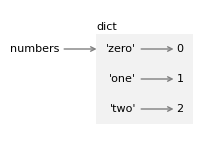

In [4]:
from shared.diagram import diagram, adjust, Bbox

width, height, x, y = [1.83, 1.24, 0.49, 0.85]
ax = diagram(width, height)
bbox = binding1.draw(ax, x, y)
# adjust(x, y, bbox)

## When to Use a Dictionary

You use a dictionary when:
- You need labeled data
- You want fast lookups by name
- You need a mapping relationship

Examples of dictionaries:

- Student records
- **Configuration** settings
- Word counts
- **JSON** data

## Creating Dictionaries

Python provides several ways to create a dictionary, depending on whether you already have the data or are building it incrementally. T 

1. **dict literal**: the most common approach to create a dictionary
2. `dict()` constructor: to turn sequences into dictionaries
3. dictionary comprehensions: are useful when keys and values come from other sources

```{index} dict() constructor, dictionary literal, dict comprehension
```

Python also has a `dict.fromkeys()` method, which is a special case in creating dictionaries. Overall, common ways ways to create a dictionary include:

| # | Method | Syntax | Notes |
|---|---|---|---|
| 1 | Empty dict literal | `{}` | Fastest way to create an empty dict |
| 2 | Dict literal | `{'a': 1, 'b': 2}` | Keys and values known up front |
| 3 | `dict()` constructor | `dict(a=1, b=2)` | Keys must be valid identifiers |
| 4 | From list of tuples | `dict([('a', 1), ('b', 2)])` | Useful when pairs are already in a sequence |
| 5 | `dict.fromkeys()` | `dict.fromkeys(['a', 'b'], 0)` | All keys share the same default value |
| 6 | Dict comprehension | `{k: v for k, v in items}` | Build from any iterable with an expression |

Pay attention to ways 2, 3, and 4. We usually use dict literal for creating dictionaries but you should know how to use the `dict()` constructor to turn a sequence into a dictionary. Also, try to transfer your skill in list comprehension and tuple comprehension to dictionary comprehension. 

In [5]:
# 1. Empty dict literal
d1 = {}

# 2. Dict literal with items
d2 = {'zero': 0, 'one': 1, 'two': 2}

# 3. dict() constructor with keyword arguments (keys must be valid identifiers)
d3 = dict(zero=0, one=1, two=2)

# 4. dict() from a list of (key, value) tuples
d4 = dict([('zero', 0), ('one', 1), ('two', 2)])

# 5. dict.fromkeys() — all keys share the same default value
d5 = dict.fromkeys(['zero', 'one', 'two'], 0)

# 6. Dict comprehension
words = ['zero', 'one', 'two']
d6 = {word: idx for idx, word in enumerate(words)} # note the two variables

print("Empty literal:       ", d1)
print("Dict literal:        ", d2)
print("dict() keywords:     ", d3)
print("dict() from tuples:  ", d4)
print("dict.fromkeys():     ", d5)
print("Dict comprehension:  ", d6)

Empty literal:        {}
Dict literal:         {'zero': 0, 'one': 1, 'two': 2}
dict() keywords:      {'zero': 0, 'one': 1, 'two': 2}
dict() from tuples:   {'zero': 0, 'one': 1, 'two': 2}
dict.fromkeys():      {'zero': 0, 'one': 0, 'two': 0}
Dict comprehension:   {'zero': 0, 'one': 1, 'two': 2}


To give some details about dictionary creation, let's use the dictionary literal to create a dictionary, which is to put the items inside curly braces. 

In [6]:
numbers = {'zero': 0, 'one': 1, 'two': 2}

Each item consists of a **key** and a **value** separated by a **colon**.
The items are separated by commas and enclosed in curly braces.

Another way to create a dictionary is to use the `dict` function.
We can make an empty dictionary like this.

In [7]:
empty = dict()
empty

{}

Or, if you have a list like [ "zero", "one", "two"], you can use `enumerate()` to create a dictionary.

In [8]:
lst = ["zero", "one", "two "]

dict_words = {}
for idx, word in enumerate(lst):
    dict_words[word] = idx

print(dict_words)

{'zero': 0, 'one': 1, 'two ': 2}


And we can make a copy of a dictionary like this.

In [9]:
numbers_copy = dict(numbers)
numbers_copy

{'zero': 0, 'one': 1, 'two': 2}

It is often useful to make a copy before performing operations that modify dictionaries.